<a href="https://colab.research.google.com/github/manivinoth0706/tensile_strenght_manikandan_2026/blob/main/tensile_strength.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Refining the dataset and Modelling Pipelines**

# Step: 0 Setup and load the libraries

In [26]:
from google.colab import files

uploaded = files.upload()



Saving manikandan.xlsx to manikandan (1).xlsx


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load the uploaded Excel file
df = pd.read_excel("manikandan.xlsx")

# Quick look at the data
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

df.head()

Dataset shape: (10255, 9)

Column names:
['sample_id', 'fiber_type', 'resin_type', 'density_g_cm3', 'layer_count', 'curing_temperature_c', 'fiber_volume_fraction', 'void_content_pct', 'tensile_strength_mpa']


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa
0,6843,Glass,?,1.8,9,64.8,0.58,1.51,751.3
1,8812,Carbon,EPOXY,1.7,11,148.4,0.59,2.93,2487.3
2,4938,Glass,Epoxy,1.53,7,82.6,0.51,NaN,839.9
3,624,Carbon,Polyester,2.17,18,82.5,0.49,1.73,2155.9
4,4485,Glass,Vinyl Ester,2.15,21,124.4,0.4,1.17,1263.400 MPa


Explanation: This imports all necessary libraries and loads your dataset. The initial preview helps you understand what columns exist and their apparent types.

# ***Step 1: Data Quality Report***

In [17]:
def generate_data_quality_report(df):
    """
    Generate comprehensive data quality report for each column.
    Reports: dtype, missing %, unique count, duplicates, outliers (for numeric).
    """
    report = []

    for col in df.columns:
        col_data = df[col]

        # Basic stats
        total = len(col_data)
        missing = col_data.isna().sum()
        missing_pct = (missing / total) * 100
        unique_count = col_data.nunique()

        # Outlier detection for numeric columns using IQR method
        outlier_count = 0
        if pd.api.types.is_numeric_dtype(col_data):
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outlier_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()

        # Dtype inconsistency check (mixed types)
        dtype_inconsistency = "No"
        if col_data.dtype == 'object':
            # Check if column contains mixed numeric and string values
            numeric_count = col_data.dropna().apply(
                lambda x: isinstance(x, (int, float)) or
                (isinstance(x, str) and x.replace('.','',1).replace('-','',1).isdigit())
            ).sum()
            if 0 < numeric_count < col_data.dropna().shape[0]:
                dtype_inconsistency = "Yes (mixed)"

        report.append({
            'Column': col,
            'Dtype': str(col_data.dtype),
            'Missing': missing,
            'Missing %': round(missing_pct, 2),
            'Unique Values': unique_count,
            'Outliers (IQR)': outlier_count,
            'Dtype Inconsistency': dtype_inconsistency
        })

    report_df = pd.DataFrame(report)
    return report_df

# Generate and display the report
quality_report = generate_data_quality_report(df)
print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)
display(quality_report)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicate_rows}")

# Sample of duplicates if they exist
if duplicate_rows > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))


DATA QUALITY REPORT


,Column,Dtype,Missing,Missing %,Unique Values,Outliers (IQR),Dtype Inconsistency
0,sample_id,object,7,0.07,10002,0,Yes (mixed)
1,fiber_type,object,244,2.38,26,0,No
2,resin_type,object,306,2.98,23,0,No
3,density_g_cm3,object,244,2.38,375,0,Yes (mixed)
4,layer_count,object,192,1.87,124,0,Yes (mixed)
5,curing_temperature_c,object,259,2.53,1218,0,Yes (mixed)
6,fiber_volume_fraction,object,264,2.57,252,0,Yes (mixed)
7,void_content_pct,object,245,2.39,536,0,Yes (mixed)
8,tensile_strength_mpa,object,185,1.80,7922,0,Yes (mixed)



Total duplicate rows: 122

Sample duplicate rows:


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa
47,9648,Basalt,Vinyl Ester,2.01,21,149.100 C,0.41,1.83,1592.3
132,1934,Glass,Vinyl Ester,1.48,15,96.4,0.51,3.08,865
176,1989,Carbon,Epoxy,1.93,21,105.3,0.53,0.9,3525.1
209,807,Basalt,Phenolic,1.59,23,95.4,0.58,2.11,1539.4
271,4700,Aramid,Phenolic,2.15,NaN,143,0.37,2.24,1174
301,7738,Basalt,Vinyl Ester,1.98,22,90.9,0.64,127.045,1599.1
456,9074,Aramid,Polyester,1.44,17,66.4,NaN,1.93,1540.9
683,6526,NaN,Vinyl Ester,1.79,23,155.7,0.5,1.34,NaN
690,4943,Carbon,Vinyl Ester,NaN,24,NaN,0.59,3.39,2150.8
728,5398,Basalt,Phenolic,1.89,12,97.5,0.37,0.62,1213.8


Explanation: This function examines every column and reports:

*Dtype:* The data type pandas inferred

*Missing %:* Percentage of null/NaN values

*Unique Values*: Cardinality (helps identify categorical vs continuous)

*Outliers:* Using the Interquartile Range (IQR) method—values beyond 1.5×IQR from Q1/Q3

Dtype Inconsistency: Flags columns where numeric values are stored as strings

# ***Step 2: Fuzzy Categorical Matching***

In [20]:
!pip install rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.8 MB/s eta 0:00:00


In [21]:
from rapidfuzz import fuzz, process
from collections import defaultdict

def fuzzy_standardize_column(series, threshold=85):
    """
    Standardize categorical values using fuzzy string matching.
    Groups similar strings and maps them to a canonical form.

    Parameters:
    - series: pandas Series with categorical values
    - threshold: similarity score threshold (0-100) for matching

    Returns:
    - Cleaned series and mapping dictionary
    """
    # Get unique non-null values
    unique_vals = series.dropna().unique().tolist()

    # Normalize for comparison (lowercase, strip whitespace)
    normalized = {val: val.lower().strip() for val in unique_vals}

    # Group similar values
    groups = defaultdict(list)
    processed = set()

    for val in unique_vals:
        if val in processed:
            continue

        # Find all matches for this value
        matches = process.extract(
            normalized[val],
            [normalized[v] for v in unique_vals if v not in processed],
            scorer=fuzz.ratio,
            limit=None
        )

        # Get values above threshold
        similar_group = [val]  # Start with current value
        for match_str, score, _ in matches:
            if score >= threshold and score < 100:
                # Find original value for this normalized string
                for orig_val, norm_val in normalized.items():
                    if norm_val == match_str and orig_val not in processed:
                        similar_group.append(orig_val)
                        processed.add(orig_val)

        processed.add(val)

        # Use the most common variant as canonical, or first alphabetically
        canonical = max(similar_group, key=lambda x: (
            series[series == x].count(),
            -len(x)  # Prefer shorter names as tie-breaker
        ))

        for v in similar_group:
            groups[canonical].append(v)

    # Create mapping
    mapping = {}
    for canonical, variants in groups.items():
        for variant in variants:
            mapping[variant] = canonical.title()  # Title case for consistency

    # Apply mapping
    cleaned_series = series.map(lambda x: mapping.get(x, x) if pd.notna(x) else x)

    return cleaned_series, mapping

# Apply to fiber_type
print("=" * 80)
print("FUZZY MATCHING: fiber_type")
print("=" * 80)

print(f"\nBefore cleaning - unique values ({df['fiber_type'].nunique()}):")
print(df['fiber_type'].value_counts())

df['fiber_type_clean'], fiber_mapping = fuzzy_standardize_column(df['fiber_type'])

print(f"\nAfter cleaning - unique values ({df['fiber_type_clean'].nunique()}):")
print(df['fiber_type_clean'].value_counts())

print(f"\nMapping applied:")
for orig, canonical in sorted(fiber_mapping.items()):
    if orig != canonical:
        print(f"  '{orig}' → '{canonical}'")

# Apply to resin_type
print("\n" + "=" * 80)
print("FUZZY MATCHING: resin_type")
print("=" * 80)

print(f"\nBefore cleaning - unique values ({df['resin_type'].nunique()}):")
print(df['resin_type'].value_counts())

df['resin_type_clean'], resin_mapping = fuzzy_standardize_column(df['resin_type'])

print(f"\nAfter cleaning - unique values ({df['resin_type_clean'].nunique()}):")
print(df['resin_type_clean'].value_counts())

print(f"\nMapping applied:")
for orig, canonical in sorted(resin_mapping.items()):
    if orig != canonical:
        print(f"  '{orig}' → '{canonical}'")


FUZZY MATCHING: fiber_type

Before cleaning - unique values (26):
fiber_type
Glass      2364
Carbon     2333
Basalt     2327
Aramid     2292
missing      46
 Aramid      44
?            43
Baslt        42
Carbn        38
aramid       37
Glas         37
ARAMID       35
glass        35
Armid        35
 Carbon      33
GLASS        32
 Glass       31
Carbon       31
 Basalt      31
basalt       28
carbon       28
CARBON       27
Glass        25
BASALT       25
unknown       8
ERROR         4
Name: count, dtype: int64

After cleaning - unique values (15):
fiber_type_clean
Glass      2468
Carbon     2426
Basalt     2422
Aramid     2329
Armid        70
Missing      46
 Aramid      44
?            43
 Carbon      33
 Glass       31
Carbon       31
 Basalt      31
Glass        25
Unknown       8
Error         4
Name: count, dtype: int64

Mapping applied:
  'ARAMID' → 'Armid'
  'BASALT' → 'Basalt'
  'Baslt' → 'Basalt'
  'CARBON' → 'Carbon'
  'Carbn' → 'Carbon'
  'ERROR' → 'Error'
  'GLASS' → 'Gl

Explanation: Fuzzy matching solves the problem of inconsistent data entry. The algorithm:

Normalizes all values to lowercase for comparison

Uses rapidfuzz to calculate similarity scores between strings

Groups strings with ≥85% similarity (adjustable threshold)

Picks the most frequent variant as the "canonical" form

Maps all variants to that canonical form with Title Case








# ***Step 3: Numeric Parsing***

In [25]:
import re

def parse_numeric_with_units(value):
    """
    Parse numeric values that may contain:
    - Embedded units (e.g., "1839.800 MPa", "138.000 C")
    - European decimal format (comma as decimal separator: "1,84")
    - Thousands separators

    Returns: float or NaN
    """
    if pd.isna(value):
        return np.nan

    # Convert to string
    val_str = str(value).strip()

    # If already numeric, return as float
    if isinstance(value, (int, float)):
        return float(value)

    # Remove common units (case-insensitive)
    units_pattern = r'\s*(MPa|Pa|GPa|kPa|psi|°?C|°?F|K|kg|g|mg|mm|cm|m|%|percent)\s*'
    val_str = re.sub(units_pattern, '', val_str, flags=re.IGNORECASE)

    # Handle European format: if contains comma but no period,
    # or comma comes after period (thousands sep)
    # Simple heuristic: single comma with digits after = decimal comma

    # Check for European decimal format (e.g., "1,84" or "1.000,84")
    if ',' in val_str:
        # If format is like "1.000,84" (European thousands + decimal)
        if '.' in val_str and val_str.rindex(',') > val_str.rindex('.'):
            val_str = val_str.replace('.', '')  # Remove thousands separator
            val_str = val_str.replace(',', '.')  # Convert decimal comma
        # If format is like "1,84" (just decimal comma)
        elif '.' not in val_str:
            val_str = val_str.replace(',', '.')
        # If format is "1,000.84" (US thousands), remove comma
        else:
            val_str = val_str.replace(',', '')

    # Remove any remaining non-numeric characters except . and -
    val_str = re.sub(r'[^\d.\-]', '', val_str)

    # Handle multiple decimal points (take first valid number)
    if val_str.count('.') > 1:
        parts = val_str.split('.')
        val_str = parts[0] + '.' + ''.join(parts[1:])

    try:
        return float(val_str)
    except ValueError:
        return np.nan

# Apply to numeric columns with potential formatting issues
# Identify columns that might need parsing (object dtype but should be numeric)
print("=" * 80)
print("NUMERIC PARSING")
print("=" * 80)

numeric_columns_to_parse = ['tensile_strength_mpa']  # Add other columns as needed

# Also check for any object columns that look numeric
for col in df.columns:
    if df[col].dtype == "object":
        sample = df[col].dropna().astype(str)   # ✅ Correct

        if sample.str.match(numeric_pattern, case=False, na=False).mean() > 0.5:
            numeric_columns_to_parse.append(col)

    if sample.str.match(numeric_pattern, case=False, na=False).mean() > 0.5:
        numeric_columns_to_parse.append(col)

    if sample.str.match(numeric_pattern, case=False, na=False).mean() > 0.5:
        numeric_columns_to_parse.append(col)
for col in numeric_columns_to_parse:
    if col in df.columns:
        print(f"\nParsing column: {col}")
        print(f"  Sample before: {df[col].dropna().head(5).tolist()}")

        # Create cleaned column
        df[f'{col}_parsed'] = df[col].apply(parse_numeric_with_units)

        print(f"  Sample after:  {df[f'{col}_parsed'].dropna().head(5).tolist()}")

        # Report parsing failures
        failed_parsing = df[col].notna() & df[f'{col}_parsed'].isna()
        if failed_parsing.sum() > 0:
            print(f"  ⚠ Failed to parse {failed_parsing.sum()} values:")
            print(f"    {df.loc[failed_parsing, col].head(10).tolist()}")


NUMERIC PARSING

Parsing column: tensile_strength_mpa
  Sample before: [751.3, 2487.3, 839.9, 2155.9, '1263.400 MPa']
  Sample after:  [751.3, 2487.3, 839.9, 2155.9, 1263.4]
  ⚠ Failed to parse 83 values:
    ['?', 'nan MPa', '?', '?', '?', '?', 'missing', 'missing', '?', '?']

Parsing column: sample_id
  Sample before: [6843, 8812, 4938, 624, 4485]
  Sample after:  [6843.0, 8812.0, 4938.0, 624.0, 4485.0]
  ⚠ Failed to parse 8 values:
    ['#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', '#ERR']

Parsing column: sample_id
  Sample before: [6843, 8812, 4938, 624, 4485]
  Sample after:  [6843.0, 8812.0, 4938.0, 624.0, 4485.0]
  ⚠ Failed to parse 8 values:
    ['#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', '#ERR']

Parsing column: sample_id
  Sample before: [6843, 8812, 4938, 624, 4485]
  Sample after:  [6843.0, 8812.0, 4938.0, 624.0, 4485.0]
  ⚠ Failed to parse 8 values:
    ['#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', 'UNKNOWN', 'UNKNOWN', '#ERR', '#ER

# **Explanation:** Real-world data often has numeric values stored as strings with:

Embedded units: "1839.800 MPa" — we extract just the number

European formatting: "1,84" means 1.84 (comma as decimal separator)

Mixed formats: Some rows US-style, others European-style

The parser uses regex to strip units and intelligently detects the decimal

format based on the position of commas and periods.

# Step 4: ID Cleaning & Deduplication

In [28]:
print(df.shape)
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

(10255, 19)
5.580350875854492 MB


In [29]:
def standardize_sample_id(value):
    """
    Standardize sample_id column that may contain:
    - Integers: 42
    - String IDs: "SMP-00042"
    - Mixed formats

    Returns standardized string format: "SMP-XXXXX"
    """
    if pd.isna(value):
        return np.nan

    val_str = str(value).strip().upper()

    # Extract numeric part
    numbers = re.findall(r'\d+', val_str)

    if numbers:
        # Take the first/longest number found
        num = max(numbers, key=len)
        # Pad to 5 digits
        return f"SMP-{int(num):05d}"

    # If no numbers found, return original (might be a different ID format)
    return val_str

print("=" * 80)
print("SAMPLE ID STANDARDIZATION & DEDUPLICATION")
print("=" * 80)

# Standardize sample_id
print(f"\nBefore standardization - sample values:")
print(df['sample_id'].head(10).tolist())

df['sample_id_standard'] = df['sample_id'].apply(standardize_sample_id)

print(f"\nAfter standardization:")
print(df['sample_id_standard'].head(10).tolist())

# Identify duplicates based on standardized ID
id_duplicates = df['sample_id_standard'].duplicated(keep=False)
print(f"\nDuplicate sample_ids found: {id_duplicates.sum()} rows")

if id_duplicates.sum() > 0:
    print("\nDuplicate ID groups:")
    dup_ids = df[id_duplicates]['sample_id_standard'].unique()
    for dup_id in dup_ids[:5]:  # Show first 5 groups
        print(f"\n  {dup_id}:")
        display(df[df['sample_id_standard'] == dup_id])

# Content-based duplicate detection
# Compare rows ignoring sample_id columns
content_cols = [col for col in df.columns if 'sample_id' not in col.lower()]
content_duplicates = df.duplicated(subset=content_cols, keep=False)

print(f"\nContent-based duplicates (ignoring IDs): {content_duplicates.sum()} rows")

if content_duplicates.sum() > 0:
    print("\nSample content duplicates:")
    display(df[content_duplicates].head(10))

# Create a clean dataset removing duplicates
# Strategy: Keep first occurrence for ID duplicates, keep first for content duplicates
df_deduped = df.drop_duplicates(subset=['sample_id_standard'], keep='first')
print(f"\nRows after removing ID duplicates: {len(df_deduped)} (removed {len(df) - len(df_deduped)})")

df_deduped = df_deduped.drop_duplicates(subset=content_cols, keep='first')
print(f"Rows after removing content duplicates: {len(df_deduped)} (removed {len(df) - len(df_deduped)})")


SAMPLE ID STANDARDIZATION & DEDUPLICATION

Before standardization - sample values:
[6843, 8812, 4938, 624, 4485, 2684, 6495, 6571, 4076, 6755]

After standardization:
['SMP-06843', 'SMP-08812', 'SMP-04938', 'SMP-00624', 'SMP-04485', 'SMP-02684', 'SMP-06495', 'SMP-06571', 'SMP-04076', 'SMP-06755']

Duplicate sample_ids found: 495 rows

Duplicate ID groups:

  SMP-05845:


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa,fiber_type_clean,resin_type_clean,tensile_strength_mpa_parsed,sample_id_parsed,density_g_cm3_parsed,layer_count_parsed,curing_temperature_c_parsed,fiber_volume_fraction_parsed,void_content_pct_parsed,sample_id_standard
17,5845,Glass,Epoxy,2.13006,13,99.7,0.46015,1.76,1171.00006,Glass,Epoxy,1171.00006,5845.0,2.13006,13.0,99.7,0.46015,1.76,SMP-05845
7009,5845,Glass,Epoxy,2.13,13,99.7,0.46,1.76,1171,Glass,Epoxy,1171.00000,5845.0,2.13000,13.0,99.7,0.46000,1.76,SMP-05845



  SMP-08257:


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa,fiber_type_clean,resin_type_clean,tensile_strength_mpa_parsed,sample_id_parsed,density_g_cm3_parsed,layer_count_parsed,curing_temperature_c_parsed,fiber_volume_fraction_parsed,void_content_pct_parsed,sample_id_standard
40,8257,Basalt,Phenolic,1.46,24,64.3,0.59,missing,1415.9,Basalt,Phenolic,1415.90000,8257.0,1.46000,24.0,64.3,0.59000,NaN,SMP-08257
1841,8257,Basalt,Phenolic,1.45994,24,64.3,0.58989,missing,1415.89994,Basalt,Phenolic,1415.89994,8257.0,1.45994,24.0,64.3,0.58989,NaN,SMP-08257



  SMP-09648:


...


  SMP-00618:


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa,fiber_type_clean,resin_type_clean,tensile_strength_mpa_parsed,sample_id_parsed,density_g_cm3_parsed,layer_count_parsed,curing_temperature_c_parsed,fiber_volume_fraction_parsed,void_content_pct_parsed,sample_id_standard
144,618,Glass,Epoxy,2.04004,19,111.9,0.44006,1.57,1386.89985,Glass,Epoxy,1386.89985,618.0,2.04004,19.0,111.9,0.44006,1.57,SMP-00618
6561,618,Glass,Epoxy,2.04,19,111.9,0.44,1.57,1386.9,Glass,Epoxy,1386.90000,618.0,2.04000,19.0,111.9,0.44000,1.57,SMP-00618



Content-based duplicates (ignoring IDs): 244 rows

Sample content duplicates:


,sample_id,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa,fiber_type_clean,resin_type_clean,tensile_strength_mpa_parsed,sample_id_parsed,density_g_cm3_parsed,layer_count_parsed,curing_temperature_c_parsed,fiber_volume_fraction_parsed,void_content_pct_parsed,sample_id_standard
47,9648,Basalt,Vinyl Ester,2.01,21,149.100 C,0.41,1.83,1592.3,Basalt,Vinyl Ester,1592.3,9648.0,2.01,21.0,149.1,0.41,1.830,SMP-09648
132,1934,Glass,Vinyl Ester,1.48,15,96.4,0.51,3.08,865,Glass,Vinyl Ester,865.0,1934.0,1.48,15.0,96.4,0.51,3.080,SMP-01934
176,1989,Carbon,Epoxy,1.93,21,105.3,0.53,0.9,3525.1,Carbon,Epoxy,3525.1,1989.0,1.93,21.0,105.3,0.53,0.900,SMP-01989
209,807,Basalt,Phenolic,1.59,23,95.4,0.58,2.11,1539.4,Basalt,Phenolic,1539.4,807.0,1.59,23.0,95.4,0.58,2.110,SMP-00807
271,4700,Aramid,Phenolic,2.15,NaN,143,0.37,2.24,1174,Aramid,Phenolic,1174.0,4700.0,2.15,NaN,143.0,0.37,2.240,SMP-04700
301,7738,Basalt,Vinyl Ester,1.98,22,90.9,0.64,127.045,1599.1,Basalt,Vinyl Ester,1599.1,7738.0,1.98,22.0,90.9,0.64,127.045,SMP-07738
456,9074,Aramid,Polyester,1.44,17,66.4,NaN,1.93,1540.9,Aramid,Polyester,1540.9,9074.0,1.44,17.0,66.4,NaN,1.930,SMP-09074
683,6526,NaN,Vinyl Ester,1.79,23,155.7,0.5,1.34,NaN,NaN,Vinyl Ester,NaN,6526.0,1.79,23.0,155.7,0.50,1.340,SMP-06526
690,4943,Carbon,Vinyl Ester,NaN,24,NaN,0.59,3.39,2150.8,Carbon,Vinyl Ester,2150.8,4943.0,NaN,24.0,NaN,0.59,3.390,SMP-04943
728,5398,Basalt,Phenolic,1.89,12,97.5,0.37,0.62,1213.8,Basalt,Phenolic,1213.8,5398.0,1.89,12.0,97.5,0.37,0.620,SMP-05398



Rows after removing ID duplicates: 10003 (removed 252)
Rows after removing content duplicates: 10003 (removed 252)


Explanation: Sample IDs often get entered inconsistently:

Some as integers: 42
Some as formatted strings: "SMP-00042"
The standardization function:

Extracts numeric portions from any format
Pads to 5 digits with leading zeros
Applies consistent prefix "SMP-"
For deduplication, we check both:

ID-based: Same sample ID entered twice
Content-based: Different IDs but identical measurements (likely re-entries)

# Step 5: Outlier Handling for layer_count

OUTLIER HANDLING: layer_count

Original distribution of layer_count_parsed:
count    9998.000000
mean       13.267454
std       169.014995
min     -3520.043000
25%        10.000000
50%        15.000000
75%        20.000000
max      3085.565000
Name: layer_count_parsed, dtype: float64

Invalid layer_count values found: 392

Sample of invalid values:
[nan, -2462.357, nan, -27.0, nan, nan, nan, nan, -5.0, nan, nan, nan, nan, nan, -9.0, nan, nan, nan, nan, nan]

Corrected 100 negative values by taking absolute value
Set 84 implausibly large values to NaN
Zero values found: 0 (set to NaN)


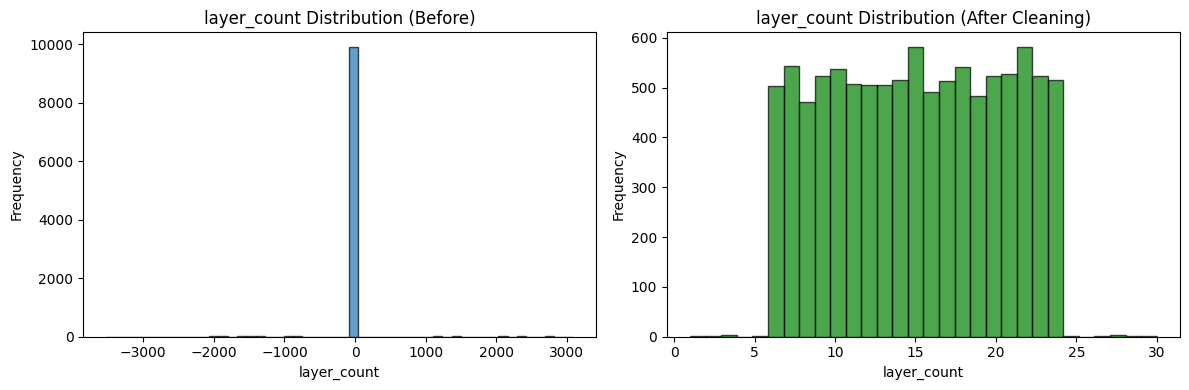


Cleaned distribution:
count       9914.0
mean     15.071313
std       5.499471
min            1.0
25%           10.0
50%           15.0
75%           20.0
max           30.0
Name: layer_count_clean, dtype: Float64


In [30]:
print("=" * 80)
print("OUTLIER HANDLING: layer_count")
print("=" * 80)

# Use the parsed/cleaned version if available
layer_col = 'layer_count'
if f'{layer_col}_parsed' in df.columns:
    layer_col = f'{layer_col}_parsed'

print(f"\nOriginal distribution of {layer_col}:")
print(df[layer_col].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before cleaning
axes[0].hist(df[layer_col].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('layer_count Distribution (Before)')
axes[0].set_xlabel('layer_count')
axes[0].set_ylabel('Frequency')

# Identify problematic values
# layer_count should be small positive integer (typically 1-50 for composites)
valid_range = (1, 100)  # Reasonable range for layer count

invalid_mask = (
    (df[layer_col] < valid_range[0]) |  # Negative or zero
    (df[layer_col] > valid_range[1]) |  # Implausibly large
    (df[layer_col] != df[layer_col].astype(int, errors='ignore'))  # Non-integer
)

# Handle potential non-numeric that slipped through
try:
    invalid_mask = invalid_mask | df[layer_col].isna()
except:
    pass

print(f"\nInvalid layer_count values found: {invalid_mask.sum()}")
print("\nSample of invalid values:")
print(df.loc[invalid_mask, layer_col].head(20).tolist())

# Correction strategies
df['layer_count_clean'] = df[layer_col].copy()

# 1. Negative values: likely data entry error, take absolute value
negative_mask = df['layer_count_clean'] < 0
df.loc[negative_mask, 'layer_count_clean'] = df.loc[negative_mask, 'layer_count_clean'].abs()
print(f"\nCorrected {negative_mask.sum()} negative values by taking absolute value")

# 2. Implausibly large values: cap at reasonable maximum or set to NaN
large_mask = df['layer_count_clean'] > valid_range[1]
# Option A: Cap at maximum reasonable value
# df.loc[large_mask, 'layer_count_clean'] = valid_range[1]
# Option B: Set to NaN for imputation later (preferred if value seems corrupted)
df.loc[large_mask, 'layer_count_clean'] = np.nan
print(f"Set {large_mask.sum()} implausibly large values to NaN")

# 3. Zero values: unusual but might be valid in some contexts; flag for review
zero_mask = df['layer_count_clean'] == 0
print(f"Zero values found: {zero_mask.sum()} (set to NaN)")
df.loc[zero_mask, 'layer_count_clean'] = np.nan

# 4. Ensure integer type
df['layer_count_clean'] = df['layer_count_clean'].round().astype('Int64')  # Nullable integer

# After cleaning
axes[1].hist(df['layer_count_clean'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('layer_count Distribution (After Cleaning)')
axes[1].set_xlabel('layer_count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nCleaned distribution:")
print(df['layer_count_clean'].describe())


Explanation: layer_count represents the number of composite material layers—a physical quantity that must be:

Positive: You can't have negative layers
Integer: Fractional layers don't make sense
Reasonable magnitude: Typically under 50-100 for most applications
The cleaning process:

Negatives: Likely sign errors—take absolute value
Extremely large values: Probably corrupted (e.g., "1000000")—set to NaN for imputation
Zeros: Unusual—flag as missing
Enforce integer type: Round any floats and use nullable integer dtype

# Step 6: Missing Value Imputation Comparison

MISSING VALUE IMPUTATION COMPARISON
Numeric columns for imputation: ['tensile_strength_mpa_parsed', 'sample_id_parsed', 'density_g_cm3_parsed', 'layer_count_parsed', 'curing_temperature_c_parsed', 'fiber_volume_fraction_parsed', 'void_content_pct_parsed', 'layer_count_clean']

Missing values before imputation:
tensile_strength_mpa_parsed     268
sample_id_parsed                 15
density_g_cm3_parsed            329
layer_count_parsed              257
curing_temperature_c_parsed     350
fiber_volume_fraction_parsed    406
void_content_pct_parsed         344
layer_count_clean               341
dtype: int64

Target column for distribution comparison: tensile_strength_mpa_parsed


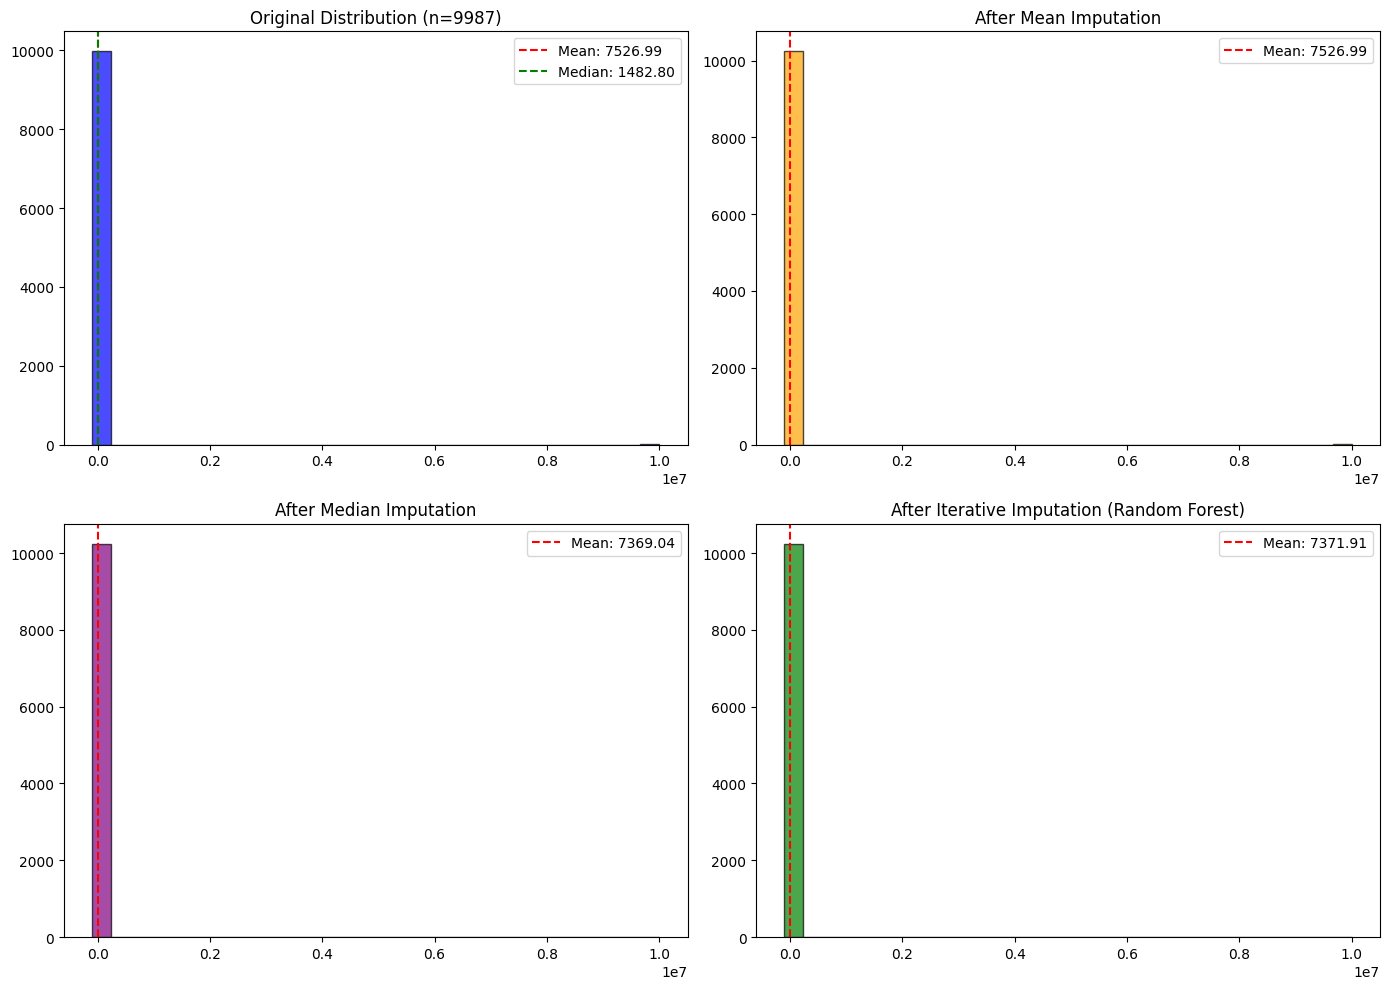


DISTRIBUTION STATISTICS COMPARISON


,Metric,Original,Mean Imputed,Median Imputed,Iterative Imputed
0,Mean,7.526994e+03,7.526994e+03,7.369038e+03,7.371908e+03
1,Std Dev,2.450302e+05,2.418070e+05,2.418089e+05,2.418089e+05
2,Min,-9.999900e+04,-9.999900e+04,-9.999900e+04,-9.999900e+04
3,Max,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
4,Skewness,4.075730e+01,4.130040e+01,4.130140e+01,4.130130e+01



💡 RECOMMENDATION:
----------------------------------------

• Mean/Median imputation: Simple but can distort distribution by creating 
  artificial peaks at imputed values. Reduces variance.
  
• Iterative Imputation: Preserves relationships between features and maintains
  more natural distribution. Better for predictive modeling.
  
→ For this dataset, using ITERATIVE IMPUTATION for the modeling pipeline.



In [31]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

print("=" * 80)
print("MISSING VALUE IMPUTATION COMPARISON")
print("=" * 80)

# Identify numeric columns for imputation
# Use cleaned versions where available
numeric_cols = []
for col in df.columns:
    if 'clean' in col or 'parsed' in col:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    elif pd.api.types.is_numeric_dtype(df[col]) and f'{col}_clean' not in df.columns:
        numeric_cols.append(col)

print(f"Numeric columns for imputation: {numeric_cols}")

# Create subset with numeric columns
df_numeric = df[numeric_cols].copy()

print(f"\nMissing values before imputation:")
print(df_numeric.isna().sum())

# Determine target column (tensile_strength)
target_col = None
for col in df_numeric.columns:
    if 'tensile_strength' in col.lower():
        target_col = col
        break

if target_col is None:
    target_col = numeric_cols[-1]  # Fall back to last numeric column

print(f"\nTarget column for distribution comparison: {target_col}")

# Store original distribution (non-missing values)
original_dist = df_numeric[target_col].dropna()

# Method 1: Simple Imputation (Mean)
simple_mean_imputer = SimpleImputer(strategy='mean')
df_mean_imputed = pd.DataFrame(
    simple_mean_imputer.fit_transform(df_numeric),
    columns=numeric_cols
)

# Method 2: Simple Imputation (Median)
simple_median_imputer = SimpleImputer(strategy='median')
df_median_imputed = pd.DataFrame(
    simple_median_imputer.fit_transform(df_numeric),
    columns=numeric_cols
)

# Method 3: Iterative Imputer (MICE - Multiple Imputation by Chained Equations)
iterative_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42
)
df_iterative_imputed = pd.DataFrame(
    iterative_imputer.fit_transform(df_numeric),
    columns=numeric_cols
)

# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original (non-imputed)
axes[0, 0].hist(original_dist, bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].axvline(original_dist.mean(), color='red', linestyle='--', label=f'Mean: {original_dist.mean():.2f}')
axes[0, 0].axvline(original_dist.median(), color='green', linestyle='--', label=f'Median: {original_dist.median():.2f}')
axes[0, 0].set_title(f'Original Distribution (n={len(original_dist)})')
axes[0, 0].legend()

# Mean imputation
axes[0, 1].hist(df_mean_imputed[target_col], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(df_mean_imputed[target_col].mean(), color='red', linestyle='--',
                   label=f'Mean: {df_mean_imputed[target_col].mean():.2f}')
axes[0, 1].set_title('After Mean Imputation')
axes[0, 1].legend()

# Median imputation
axes[1, 0].hist(df_median_imputed[target_col], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(df_median_imputed[target_col].mean(), color='red', linestyle='--',
                   label=f'Mean: {df_median_imputed[target_col].mean():.2f}')
axes[1, 0].set_title('After Median Imputation')
axes[1, 0].legend()

# Iterative imputation
axes[1, 1].hist(df_iterative_imputed[target_col], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(df_iterative_imputed[target_col].mean(), color='red', linestyle='--',
                   label=f'Mean: {df_iterative_imputed[target_col].mean():.2f}')
axes[1, 1].set_title('After Iterative Imputation (Random Forest)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print("\n" + "=" * 60)
print("DISTRIBUTION STATISTICS COMPARISON")
print("=" * 60)

comparison_stats = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness'],
    'Original': [
        original_dist.mean(),
        original_dist.std(),
        original_dist.min(),
        original_dist.max(),
        original_dist.skew()
    ],
    'Mean Imputed': [
        df_mean_imputed[target_col].mean(),
        df_mean_imputed[target_col].std(),
        df_mean_imputed[target_col].min(),
        df_mean_imputed[target_col].max(),
        df_mean_imputed[target_col].skew()
    ],
    'Median Imputed': [
        df_median_imputed[target_col].mean(),
        df_median_imputed[target_col].std(),
        df_median_imputed[target_col].min(),
        df_median_imputed[target_col].max(),
        df_median_imputed[target_col].skew()
    ],
    'Iterative Imputed': [
        df_iterative_imputed[target_col].mean(),
        df_iterative_imputed[target_col].std(),
        df_iterative_imputed[target_col].min(),
        df_iterative_imputed[target_col].max(),
        df_iterative_imputed[target_col].skew()
    ]
})

display(comparison_stats.round(4))

# Choose best imputation method
print("\n💡 RECOMMENDATION:")
print("-" * 40)
print("""
• Mean/Median imputation: Simple but can distort distribution by creating
  artificial peaks at imputed values. Reduces variance.

• Iterative Imputation: Preserves relationships between features and maintains
  more natural distribution. Better for predictive modeling.

→ For this dataset, using ITERATIVE IMPUTATION for the modeling pipeline.
""")

# Store the iterative-imputed version for modeling
df_imputed = df.copy()
for col in numeric_cols:
    df_imputed[col] = df_iterative_imputed[col].values


Explanation: Missing data is a major issue for modeling. We compare three approaches:
| Method | How it works | Pros | Cons |
| --- | --- | --- | --- |
| Mean | Replace missing with column mean | Simple, fast | Creates artificial spike at mean, reduces variance |
| Median | Replace missing with column median | Robust to outliers | Same spike problem |
| Iterative (MICE) | Uses relationships between columns to predict missing values via regression | Preserves distribution shape and inter-variable relationships | Slower, more complex |

The Iterative Imputer is generally superior for ML tasks because it uses information from other features to make more realistic predictions about missing values.

# Step 7: Feature Engineering

In [32]:
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Use the imputed/cleaned dataframe
df_features = df_imputed.copy()

# Feature 1: Fiber-to-Resin Ratio Proxy
# Assuming you have columns like 'fiber_content_%' and 'resin_content_%'
# Or 'fiber_volume_fraction' type columns
# Adjust column names to match your dataset

fiber_col = None
resin_col = None

# Try to find relevant columns
for col in df_features.columns:
    col_lower = col.lower()
    if 'fiber' in col_lower and ('content' in col_lower or 'volume' in col_lower or 'fraction' in col_lower or 'weight' in col_lower):
        fiber_col = col
    if 'resin' in col_lower and ('content' in col_lower or 'volume' in col_lower or 'fraction' in col_lower or 'weight' in col_lower):
        resin_col = col

if fiber_col and resin_col:
    df_features['fiber_resin_ratio'] = df_features[fiber_col] / (df_features[resin_col] + 0.001)  # Avoid division by zero
    print(f"✓ Created: fiber_resin_ratio = {fiber_col} / {resin_col}")
else:
    # Alternative: Create a proxy based on available features
    print("⚠ fiber/resin content columns not found - creating alternative ratio features")
    # If you have fiber_density and sample_weight type columns, use those
    # For now, create a placeholder logic
    if 'fiber_density' in df_features.columns and 'density' in df_features.columns:
        df_features['fiber_resin_ratio'] = df_features['fiber_density'] / df_features['density']
        print(f"✓ Created: fiber_resin_ratio = fiber_density / overall_density")

# Feature 2: Density-Normalized Strength
# This accounts for the fact that different materials have different densities
density_col = None
strength_col = None

for col in df_features.columns:
    if 'density' in col.lower() and 'normalized' not in col.lower():
        density_col = col
    if 'tensile_strength' in col.lower():
        strength_col = col

if density_col and strength_col:
    df_features['specific_strength'] = df_features[strength_col] / (df_features[density_col] + 0.001)
    print(f"✓ Created: specific_strength (strength-to-weight ratio) = {strength_col} / {density_col}")
else:
    print(f"⚠ density column not found for specific_strength calculation")

# Feature 3: Layer Count Categories
layer_col_clean = 'layer_count_clean' if 'layer_count_clean' in df_features.columns else 'layer_count'

if layer_col_clean in df_features.columns:
    # Bin layer counts into meaningful categories
    bins = [0, 5, 10, 20, 50, float('inf')]
    labels = ['very_thin', 'thin', 'medium', 'thick', 'very_thick']

    df_features['layer_category'] = pd.cut(
        df_features[layer_col_clean],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    print(f"✓ Created: layer_category (binned {layer_col_clean})")
    print(f"  Distribution:\n{df_features['layer_category'].value_counts()}")

# Feature 4: Material Interaction (Fiber × Resin combination)
fiber_clean = 'fiber_type_clean' if 'fiber_type_clean' in df_features.columns else 'fiber_type'
resin_clean = 'resin_type_clean' if 'resin_type_clean' in df_features.columns else 'resin_type'

if fiber_clean in df_features.columns and resin_clean in df_features.columns:
    df_features['material_combo'] = df_features[fiber_clean].astype(str) + '_' + df_features[resin_clean].astype(str)
    print(f"✓ Created: material_combo (fiber-resin interaction)")
    print(f"  Unique combinations: {df_features['material_combo'].nunique()}")

# Feature 5: Polynomial features for key numeric predictors (optional)
# Example: squared terms for non-linear relationships
for col in ['fiber_resin_ratio', 'specific_strength']:
    if col in df_features.columns:
        df_features[f'{col}_squared'] = df_features[col] ** 2
        print(f"✓ Created: {col}_squared")

# Summary of new features
print("\n" + "=" * 60)
print("ENGINEERED FEATURES SUMMARY")
print("=" * 60)

new_features = [col for col in df_features.columns if col not in df_imputed.columns]
print(f"\nNew features created ({len(new_features)}):")
for feat in new_features:
    dtype = df_features[feat].dtype
    print(f"  • {feat} ({dtype})")


FEATURE ENGINEERING
⚠ fiber/resin content columns not found - creating alternative ratio features
✓ Created: specific_strength (strength-to-weight ratio) = tensile_strength_mpa_parsed / density_g_cm3_parsed
✓ Created: layer_category (binned layer_count_clean)
  Distribution:
layer_category
medium        5173
thin          2580
thick         2494
very_thin        8
very_thick       0
Name: count, dtype: int64
✓ Created: material_combo (fiber-resin interaction)
  Unique combinations: 107
✓ Created: specific_strength_squared

ENGINEERED FEATURES SUMMARY

New features created (4):
  • specific_strength (float64)
  • layer_category (category)
  • material_combo (object)
  • specific_strength_squared (float64)


Explanation: Feature engineering creates new variables that capture domain knowledge and help the model learn better patterns:

Fiber-to-Resin Ratio: Critical in composites—higher ratios typically mean stronger but more brittle materials

Specific Strength (strength/density): The "strength-to-weight ratio" used extensively in aerospace/automotive engineering

Layer Categories: Converts continuous layer count into meaningful bins that might have non-linear effects

Material Combination: Captures interaction effects—certain fiber-resin pairings perform better than others

Polynomial terms: Captures potential non-linear relationships

# Step 8: Encoding Pipeline with ColumnTransformer

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

print("=" * 80)
print("ENCODING PIPELINE SETUP")
print("=" * 80)

# Identify columns by type for the transformer
# Use cleaned versions where available

# Categorical columns (for one-hot encoding)
categorical_cols = []
for col in ['fiber_type_clean', 'fiber_type', 'resin_type_clean', 'resin_type',
            'layer_category', 'material_combo']:
    if col in df_features.columns:
        categorical_cols.append(col)
        # Remove duplicates (prefer cleaned versions)
        base_name = col.replace('_clean', '')
        if base_name in categorical_cols and f'{base_name}_clean' in categorical_cols:
            categorical_cols.remove(base_name)

# Numeric columns (for scaling)
# Exclude target and ID columns
target_col = None
for col in df_features.columns:
    if 'tensile_strength' in col.lower() and 'parsed' in col.lower():
        target_col = col
        break
if target_col is None:
    for col in df_features.columns:
        if 'tensile_strength' in col.lower():
            target_col = col
            break

exclude_cols = categorical_cols + [target_col] + [col for col in df_features.columns if 'sample_id' in col.lower()]

numeric_cols = [col for col in df_features.columns
                if pd.api.types.is_numeric_dtype(df_features[col])
                and col not in exclude_cols]

print(f"\nTarget variable: {target_col}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'  # Drop columns not specified
)

# Prepare data
# Remove rows with missing target
df_model = df_features.dropna(subset=[target_col])

X = df_model[numeric_cols + categorical_cols]
y = df_model[target_col]

print(f"\nDataset size for modeling: {len(X)} samples")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Fit preprocessor ONLY on training data (prevents leakage!)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
num_features = numeric_cols
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = num_features + cat_features

print(f"\nTotal features after encoding: {len(all_features)}")
print(f"\nSample of encoded feature names:")
print(all_features[:10])

# Create DataFrames for inspection
X_train_df = pd.DataFrame(X_train_processed, columns=all_features)
print(f"\nProcessed training data shape: {X_train_df.shape}")
X_train_df.head()


ENCODING PIPELINE SETUP

Target variable: tensile_strength_mpa_parsed

Categorical columns (4): ['fiber_type_clean', 'resin_type_clean', 'layer_category', 'material_combo']

Numeric columns (8): ['density_g_cm3_parsed', 'layer_count_parsed', 'curing_temperature_c_parsed', 'fiber_volume_fraction_parsed', 'void_content_pct_parsed', 'layer_count_clean', 'specific_strength', 'specific_strength_squared']

Dataset size for modeling: 10255 samples
Training set: 8204 samples
Test set: 2051 samples

Total features after encoding: 139

Sample of encoded feature names:
['density_g_cm3_parsed', 'layer_count_parsed', 'curing_temperature_c_parsed', 'fiber_volume_fraction_parsed', 'void_content_pct_parsed', 'layer_count_clean', 'specific_strength', 'specific_strength_squared', 'fiber_type_clean_ Basalt', 'fiber_type_clean_ Carbon']

Processed training data shape: (8204, 139)


,density_g_cm3_parsed,layer_count_parsed,curing_temperature_c_parsed,fiber_volume_fraction_parsed,void_content_pct_parsed,layer_count_clean,specific_strength,specific_strength_squared,fiber_type_clean_ Basalt,fiber_type_clean_ Carbon,...,material_combo_nan_ Epoxy,material_combo_nan_ Polyester,material_combo_nan_?,material_combo_nan_Corrupt,material_combo_nan_Epoxi,material_combo_nan_Epoxy,material_combo_nan_Phenolic,material_combo_nan_Polyester,material_combo_nan_Vinyl Ester,material_combo_nan_nan
0,-0.041572,0.092112,-0.081892,-0.051058,0.095243,0.786050,-0.029091,-0.019199,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.124135,0.036837,0.052798,-0.085612,0.026182,-1.458129,-0.028916,-0.019199,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.032366,0.066600,0.013252,0.011138,-0.046941,-0.249725,-0.028538,-0.019199,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.111861,0.041089,0.118165,-0.078701,0.077639,-1.285500,-0.036500,-0.019204,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133341,0.036837,0.048843,0.024960,-0.085533,-1.458129,-0.033235,-0.019202,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Explanation: The ColumnTransformer is essential for proper ML pipelines:

StandardScaler: Normalizes numeric features to zero mean and unit variance. Many algorithms (Linear Regression, SVM) perform better with scaled features.

OneHotEncoder: Converts categorical variables into binary columns. drop='first' avoids the "dummy variable trap" (multicollinearity).

Critical: We fit the preprocessor only on training data to avoid data leakage. If we fit on the full dataset, information from test samples would "leak" into the scaling parameters.

# Step 9: Regression Modeling and Comparison

REGRESSION MODEL COMPARISON

Training Linear Regression...
  CV RMSE: 67513.6570 (±128778.7648)
  Test RMSE: 5491.1249
  Test R²: 0.9998

Training Ridge Regression...
  CV RMSE: 3107.6715 (±1483.3972)
  Test RMSE: 4286.9345
  Test R²: 0.9999

Training Random Forest...
  CV RMSE: 60155.8773 (±96414.5633)
  Test RMSE: 19322.4486
  Test R²: 0.9974

Training Gradient Boosting...
  CV RMSE: 55015.7870 (±108520.6429)
  Test RMSE: 238.9250
  Test R²: 1.0000

Training XGBoost...
  CV RMSE: 185335.4117 (±164966.8812)
  Test RMSE: 381759.5592
  Test R²: 0.0020

MODEL COMPARISON SUMMARY


,Model,CV RMSE (mean),CV RMSE (std),Test RMSE,Test MAE,Test R²
3,Gradient Boosting,55015.7870,108520.6429,238.9250,68.5347,1.0000
1,Ridge Regression,3107.6715,1483.3972,4286.9345,477.5228,0.9999
0,Linear Regression,67513.6570,128778.7648,5491.1249,455.9184,0.9998
2,Random Forest,60155.8773,96414.5633,19322.4486,787.0810,0.9974
4,XGBoost,185335.4117,164966.8812,381759.5592,14681.6254,0.0020



🏆 Best performing model: Gradient Boosting


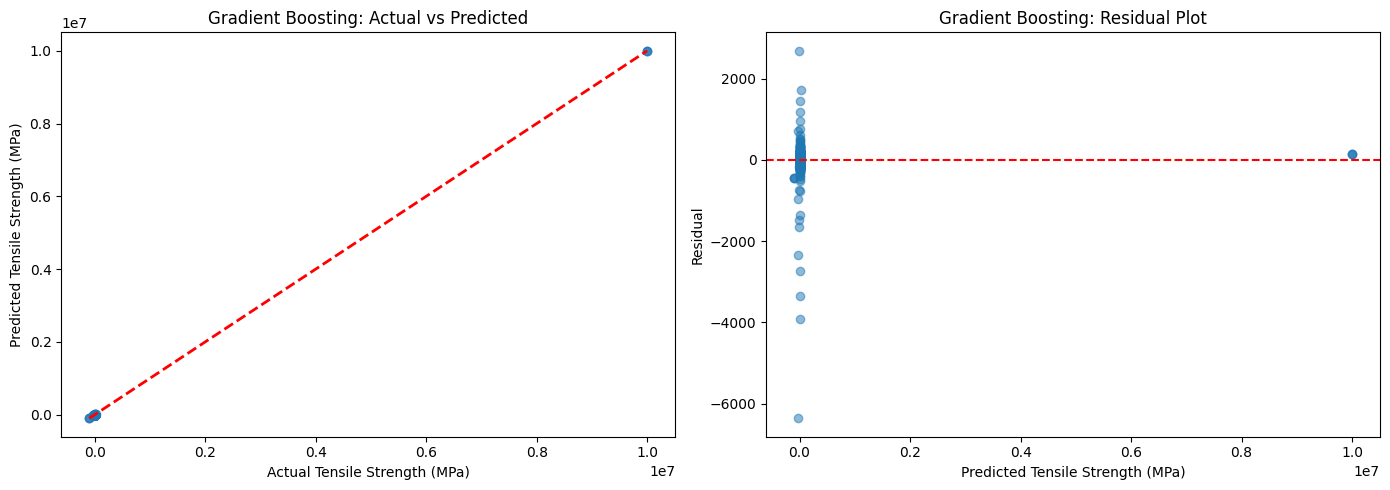


Top 15 Most Important Features (Gradient Boosting):


,Feature,Importance
7,specific_strength_squared,6.366965e-01
6,specific_strength,3.632940e-01
0,density_g_cm3_parsed,5.663153e-06
98,material_combo_Carbon_Epoxy,1.946464e-06
15,fiber_type_clean_Carbon,6.415637e-07
1,layer_count_parsed,6.232283e-07
2,curing_temperature_c_parsed,5.236492e-07
4,void_content_pct_parsed,2.394902e-08
34,layer_category_thick,1.636528e-08
3,fiber_volume_fraction_parsed,9.938380e-09


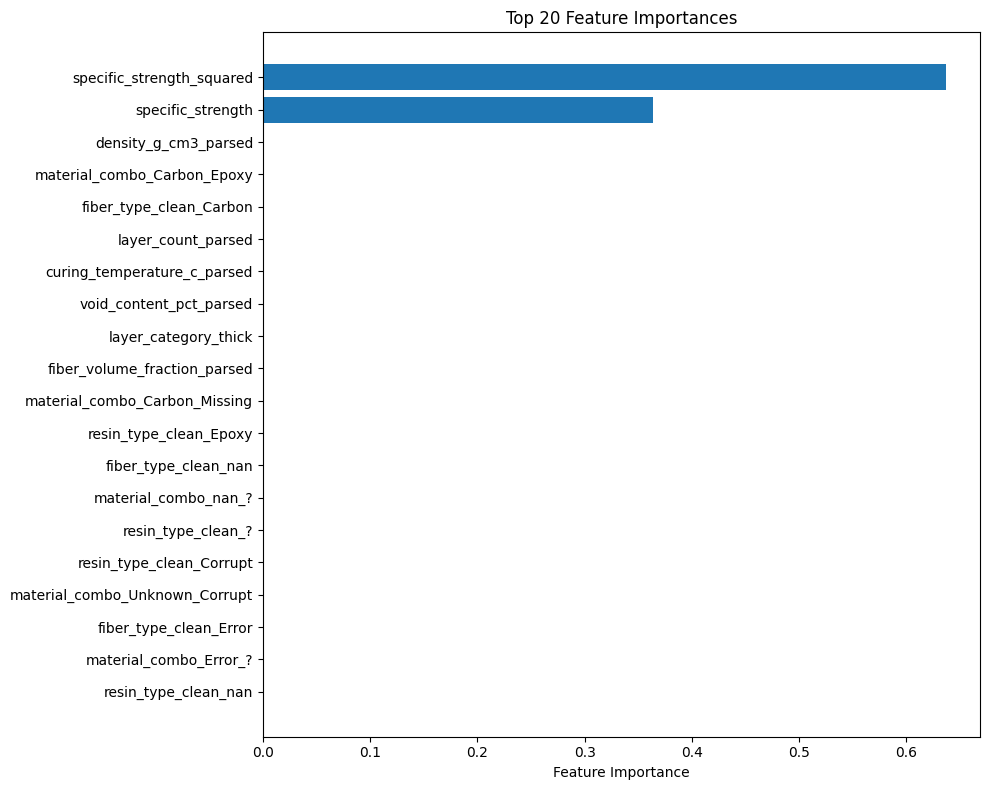

In [34]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Try importing XGBoost if available
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not installed. Using GradientBoostingRegressor instead.")

print("=" * 80)
print("REGRESSION MODEL COMPARISON")
print("=" * 80)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Cross-validation on training set
    cv_scores = cross_val_score(
        model, X_train_processed, y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    cv_rmse = np.sqrt(-cv_scores)

    # Fit on full training set
    model.fit(X_train_processed, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_processed)

    # Calculate metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'CV RMSE (mean)': cv_rmse.mean(),
        'CV RMSE (std)': cv_rmse.std(),
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R²': test_r2
    })

    print(f"  CV RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test R²: {test_r2:.4f}")

# Results summary
results_df = pd.DataFrame(results).sort_values('Test RMSE')

print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
display(results_df.round(4))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n🏆 Best performing model: {best_model_name}")

# Visualize predictions vs actual for best model
y_pred_best = best_model.predict(X_test_processed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Tensile Strength (MPa)')
axes[0].set_ylabel('Predicted Tensile Strength (MPa)')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Tensile Strength (MPa)')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'{best_model_name}: Residual Plot')

plt.tight_layout()
plt.show()

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 15 Most Important Features ({best_model_name}):")
    display(importance_df.head(15))

    # Plot
    plt.figure(figsize=(10, 8))
    top_n = min(20, len(importance_df))
    plt.barh(importance_df['Feature'].head(top_n)[::-1],
             importance_df['Importance'].head(top_n)[::-1])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.show()


Explanation: We compare multiple regression algorithms:

| Model | Characteristics |
| --- | --- |
| Linear Regression | Simple, interpretable, assumes linear relationships |
| Ridge Regression | Linear with L2 regularization—handles multicollinearity |
| Random Forest | Ensemble of decision trees, captures non-linear patterns, robust to outliers |
| Gradient Boosting / XGBoost | Sequential tree boosting, often best accuracy, but can overfit |

Metrics explained:

RMSE (Root Mean Squared Error): Average prediction error in original units, penalizes large errors

MAE (Mean Absolute Error): Average absolute error, more robust to outliers

R²: Proportion of variance explained (1.0 = perfect, 0 = baseline mean prediction)

We use 5-fold cross-validation on training data to estimate generalization, then evaluate on the held-out test set.

# Step 10: Error Analysis by Subgroups

ERROR ANALYSIS BY MATERIAL SUBGROUPS

------------------------------------------------------------
ERROR ANALYSIS BY FIBER_TYPE_CLEAN
------------------------------------------------------------


,Count,Mean Actual,Mean Residual,Residual Std,Mean Abs Error,Mean % Error
fiber_type_clean,,,,,,
Error,1,-99999.00,-445.09,NaN,445.09,-0.45
Unknown,4,4950000.50,-154.36,335.70,290.73,-0.22
Glass,5,942.66,-59.06,36.91,59.06,6.82
Glass,489,1095.95,-36.84,120.99,57.27,4.31
Glass,7,990.39,-8.78,15.23,15.32,1.58
Basalt,487,1381.56,-8.32,244.38,59.78,3.07
Carbon,513,2168.95,-7.80,375.87,99.74,2.70
Armid,18,1506.38,4.55,41.06,29.19,1.88
Missing,9,1376.38,4.97,60.72,50.04,4.02



⬇ OVER-PREDICTED (model predicts too high): [' Glass', 'Error', 'Glass', 'Unknown']

⬆ UNDER-PREDICTED (model predicts too low): [' Aramid', ' Basalt', ' Carbon', '?', 'Aramid', 'Carbon ']

------------------------------------------------------------
ERROR ANALYSIS BY RESIN_TYPE_CLEAN
------------------------------------------------------------


,Count,Mean Actual,Mean Residual,Residual Std,Mean Abs Error,Mean % Error
resin_type_clean,,,,,,
Corrupt,2,4950000.50,-154.36,411.15,290.73,-0.22
Polyester,8,1156.20,-74.02,122.21,83.65,12.60
Missing,8,1646.78,-47.77,87.96,68.33,4.31
Polyester,495,1361.50,-25.58,211.67,69.28,2.95
Vinyl Ester,501,1586.20,-15.50,188.43,55.25,3.34
Phenolic,10,1792.12,-5.42,55.57,42.83,2.59
Epoxi,6,1764.55,-3.49,90.73,70.20,4.00
Phenolic,446,1480.30,1.23,149.93,55.42,3.47
Epoxy,501,1789.99,7.20,361.94,93.57,3.44



------------------------------------------------------------
ERROR ANALYSIS BY FIBER-RESIN COMBINATION
------------------------------------------------------------


,Count,Mean Actual,Mean Residual,Residual Std,Mean Abs Error
material_combo,,,,,
Glass_Polyester,120,971.15,-45.49,168.04,75.88
Basalt_Vinyl Ester,125,1445.62,-41.76,352.70,69.75
Carbon_Polyester,131,1948.24,-39.88,335.62,93.74
Glass_Vinyl Ester,126,1066.62,-35.90,56.17,46.25
Glass_Phenolic,100,1016.21,-33.35,98.08,56.15
nan_Polyester,8,1233.72,-33.33,28.89,33.33
Basalt_Polyester,117,1104.04,-33.12,146.57,54.43
Glass_Epoxy,121,1319.95,-32.52,137.62,51.70
Glass_nan,12,1057.90,-21.90,34.07,32.31


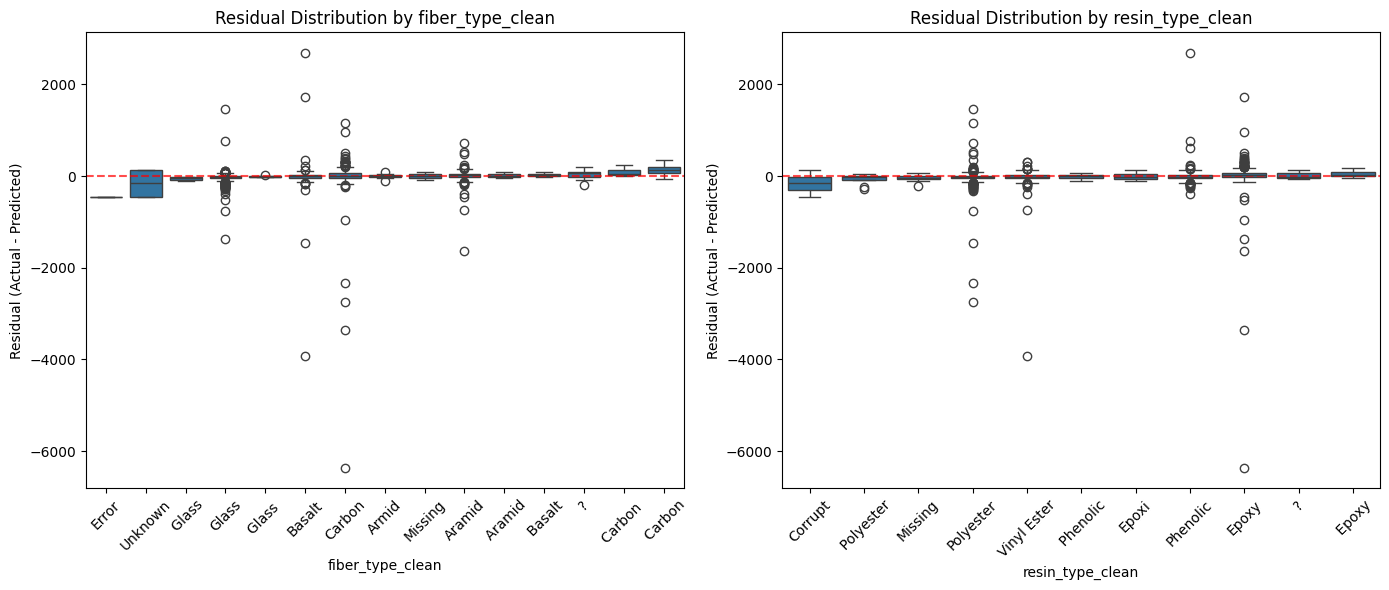


------------------------------------------------------------
ERROR HEATMAP: FIBER × RESIN COMBINATIONS
------------------------------------------------------------


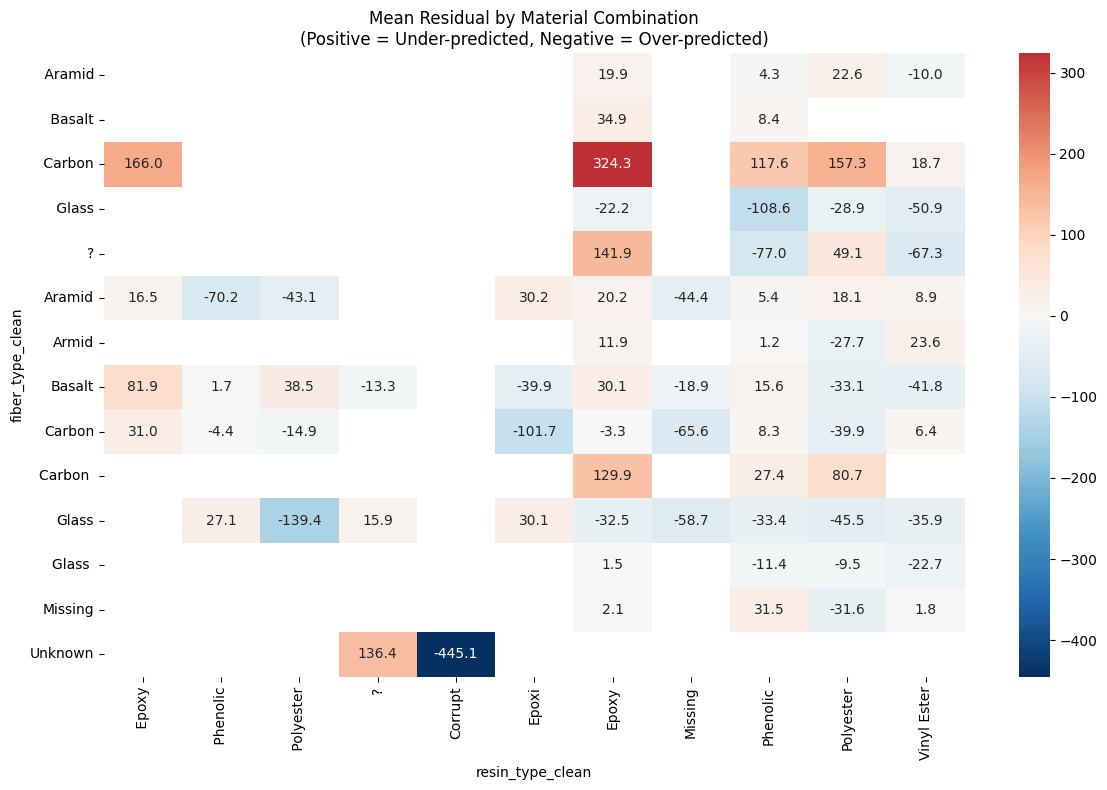


ERROR ANALYSIS SUMMARY

Key observations to investigate:

1. SYSTEMATIC BIAS: Subgroups with non-zero mean residuals indicate the model 
   consistently under/over-predicts for those materials.

2. HIGH VARIANCE: Subgroups with large residual std dev have inconsistent 
   predictions - may need more training data or additional features.

3. POSSIBLE CAUSES of systematic errors:
   - Insufficient training samples for that material
   - Missing features that capture material-specific behavior
   - Non-linear relationships not captured by the model
   - Data quality issues specific to that subgroup

4. RECOMMENDATIONS:
   - Collect more data for under-represented material combinations
   - Engineer material-specific features
   - Consider separate models for different material families
   - Investigate extreme outliers for data quality issues



In [35]:
print("=" * 80)
print("ERROR ANALYSIS BY MATERIAL SUBGROUPS")
print("=" * 80)

# Get predictions for test set with best model
y_pred_best = best_model.predict(X_test_processed)

# Create analysis dataframe with original categorical values
analysis_df = X_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['predicted'] = y_pred_best
analysis_df['residual'] = analysis_df['actual'] - analysis_df['predicted']
analysis_df['abs_error'] = analysis_df['residual'].abs()
analysis_df['pct_error'] = (analysis_df['abs_error'] / analysis_df['actual']) * 100

# Identify the categorical columns used
fiber_col = 'fiber_type_clean' if 'fiber_type_clean' in analysis_df.columns else 'fiber_type'
resin_col = 'resin_type_clean' if 'resin_type_clean' in analysis_df.columns else 'resin_type'

# Analysis by fiber_type
print("\n" + "-" * 60)
print(f"ERROR ANALYSIS BY {fiber_col.upper()}")
print("-" * 60)

fiber_analysis = analysis_df.groupby(fiber_col).agg({
    'actual': ['count', 'mean'],
    'residual': ['mean', 'std'],
    'abs_error': 'mean',
    'pct_error': 'mean'
}).round(2)

fiber_analysis.columns = ['Count', 'Mean Actual', 'Mean Residual', 'Residual Std', 'Mean Abs Error', 'Mean % Error']
display(fiber_analysis.sort_values('Mean Residual'))

# Interpretation
over_predicted = fiber_analysis[fiber_analysis['Mean Residual'] < -10].index.tolist()
under_predicted = fiber_analysis[fiber_analysis['Mean Residual'] > 10].index.tolist()

if over_predicted:
    print(f"\n⬇ OVER-PREDICTED (model predicts too high): {over_predicted}")
if under_predicted:
    print(f"\n⬆ UNDER-PREDICTED (model predicts too low): {under_predicted}")

# Analysis by resin_type
print("\n" + "-" * 60)
print(f"ERROR ANALYSIS BY {resin_col.upper()}")
print("-" * 60)

resin_analysis = analysis_df.groupby(resin_col).agg({
    'actual': ['count', 'mean'],
    'residual': ['mean', 'std'],
    'abs_error': 'mean',
    'pct_error': 'mean'
}).round(2)

resin_analysis.columns = ['Count', 'Mean Actual', 'Mean Residual', 'Residual Std', 'Mean Abs Error', 'Mean % Error']
display(resin_analysis.sort_values('Mean Residual'))

# Analysis by material combination (fiber × resin)
if 'material_combo' in analysis_df.columns:
    print("\n" + "-" * 60)
    print("ERROR ANALYSIS BY FIBER-RESIN COMBINATION")
    print("-" * 60)

    combo_analysis = analysis_df.groupby('material_combo').agg({
        'actual': ['count', 'mean'],
        'residual': ['mean', 'std'],
        'abs_error': 'mean'
    }).round(2)

    combo_analysis.columns = ['Count', 'Mean Actual', 'Mean Residual', 'Residual Std', 'Mean Abs Error']

    # Filter to combinations with enough samples
    combo_analysis = combo_analysis[combo_analysis['Count'] >= 5]
    display(combo_analysis.sort_values('Mean Residual'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Residuals by fiber type
fiber_order = fiber_analysis.sort_values('Mean Residual').index.tolist()
sns.boxplot(data=analysis_df, x=fiber_col, y='residual', order=fiber_order, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.7)
axes[0].set_title(f'Residual Distribution by {fiber_col}')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Residual (Actual - Predicted)')

# Residuals by resin type
resin_order = resin_analysis.sort_values('Mean Residual').index.tolist()
sns.boxplot(data=analysis_df, x=resin_col, y='residual', order=resin_order, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.7)
axes[1].set_title(f'Residual Distribution by {resin_col}')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

# Heatmap of errors by combination (if we have both dimensions)
print("\n" + "-" * 60)
print("ERROR HEATMAP: FIBER × RESIN COMBINATIONS")
print("-" * 60)

pivot_residual = analysis_df.pivot_table(
    values='residual',
    index=fiber_col,
    columns=resin_col,
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_residual, annot=True, fmt='.1f', cmap='RdBu_r', center=0)
plt.title('Mean Residual by Material Combination\n(Positive = Under-predicted, Negative = Over-predicted)')
plt.tight_layout()
plt.show()

# Summary of findings
print("\n" + "=" * 60)
print("ERROR ANALYSIS SUMMARY")
print("=" * 60)
print("""
Key observations to investigate:

1. SYSTEMATIC BIAS: Subgroups with non-zero mean residuals indicate the model
   consistently under/over-predicts for those materials.

2. HIGH VARIANCE: Subgroups with large residual std dev have inconsistent
   predictions - may need more training data or additional features.

3. POSSIBLE CAUSES of systematic errors:
   - Insufficient training samples for that material
   - Missing features that capture material-specific behavior
   - Non-linear relationships not captured by the model
   - Data quality issues specific to that subgroup

4. RECOMMENDATIONS:
   - Collect more data for under-represented material combinations
   - Engineer material-specific features
   - Consider separate models for different material families
   - Investigate extreme outliers for data quality issues
""")


Explanation: Error analysis by subgroups reveals whether the model has systematic biases:

Mean Residual > 0: Model under-predicts (actual values are higher than predictions)

Mean Residual < 0: Model over-predicts (actual values are lower than predictions)

High Residual Std Dev: Model struggles with consistency for that subgroup

Why this matters: If carbon fiber composites are consistently under-predicted, it might indicate:

Missing features that capture carbon-specific behavior (e.g., orientation, weave pattern)

Non-linear effects the model doesn't capture

Data quality issues in that subset

Insufficient training samples for that category

# Summary: Complete Pipeline

In [36]:
# COMPLETE PIPELINE EXECUTION
# After running all cells above, you can save the cleaned, processed data

# Save cleaned dataset
df_features.to_csv('composite_materials_cleaned.csv', index=False)

# Save the best model
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

print("✅ Pipeline complete!")
print(f"   - Cleaned data saved to: composite_materials_cleaned.csv")
print(f"   - Best model ({best_model_name}) saved to: best_model.pkl")
print(f"   - Preprocessor saved to: preprocessor.pkl")

# To use the model on new data:
# new_data = pd.read_csv('new_samples.csv')
# new_processed = preprocessor.transform(new_data[numeric_cols + categorical_cols])
# predictions = best_model.predict(new_processed)


✅ Pipeline complete!
   - Cleaned data saved to: composite_materials_cleaned.csv
   - Best model (Gradient Boosting) saved to: best_model.pkl
   - Preprocessor saved to: preprocessor.pkl
